In [3]:
import os

files = os.listdir("FingeringFiles")
print(f"sum files: {len(files)}")

sum files: 309


In [4]:
import pandas as pd

columns = [
    "note_id", "onset_time", "offset_time", "spelled_pitch",
    "onset_velocity", "offset_velocity", "channel", "finger_number"
]

In [ ]:
sample_file = "FingeringFiles/001-1_fingering.txt"

df_sample = pd.read_csv(
    sample_file, 
    sep=r"\s+", #bu regex boşlukları tabları ayarlıyor
    comment="/", 
    header=None, 
    names=columns
)

df_sample.head()

,note_id,onset_time,offset_time,spelled_pitch,onset_velocity,offset_velocity,channel,finger_number
0,0,0.156289,0.302811,C4,64,80,0,1
1,1,0.312579,0.459100,D4,64,80,0,2
2,2,0.468869,0.615390,E4,64,80,0,3
3,3,0.625158,0.771679,F4,64,80,0,4
4,4,0.781447,0.927969,D4,64,80,0,2


In [8]:
import pandas as pd

df_list = pd.read_csv("List.csv")

composer_counts = df_list["Composer"].value_counts()

print(f"eser sayısı: {len(df_list)}")
print(composer_counts)

eser sayısı: 150
Composer
Chopin          23
Bach            22
Beethoven       21
Mozart          20
Grieg           10
Debussy          9
Schumann         6
Schubert         5
Rachmaninoff     4
Ravel            3
Mussorgsky       3
Liszt            3
Brahms           3
Joplin           3
Mendelssohn      3
Faure            2
Satie            2
Scriabin         2
Dvorak           1
Tchaikovsky      1
Scarlatti        1
Saint-Saens      1
Bartok           1
Albeniz          1
Name: count, dtype: int64


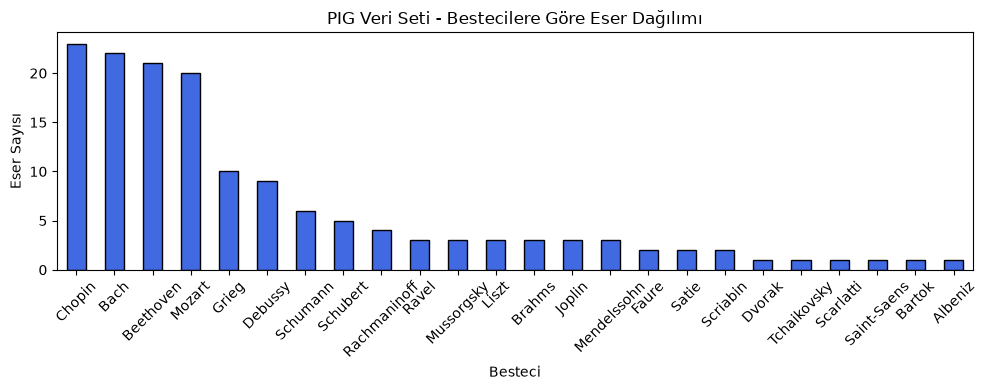

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
composer_counts.plot(kind="bar", color="royalblue", edgecolor="black")
plt.title("PIG Veri Seti - Bestecilere Göre Eser Dağılımı")
plt.xlabel("Besteci")
plt.ylabel("Eser Sayısı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import music21

df_sample["finger_clean"] = df_sample["finger_number"].astype(str).apply(lambda x: x.split("_")[0])
df_sample["finger"] = df_sample["finger_clean"].astype(int)
df_sample["midi_pitch"] = df_sample["spelled_pitch"].apply(lambda p: music21.pitch.Pitch(p).midi)
df_sample[["onset_time", "spelled_pitch", "midi_pitch", "channel", "finger"]].head()

,onset_time,spelled_pitch,midi_pitch,channel,finger
0,0.156289,C4,60,0,1
1,0.312579,D4,62,0,2
2,0.468869,E4,64,0,3
3,0.625158,F4,65,0,4
4,0.781447,D4,62,0,2


In [12]:
import os
import glob
import pandas as pd

# Klasördeki tüm .txt dosyalarının yollarını topla
all_files = glob.glob(os.path.join("FingeringFiles", "*_fingering.txt"))

# Her dosyadan sadece 6. (channel) ve 7. (finger_number) sütunları oku
records = []
for file_path in all_files:
    df_temp = pd.read_csv(file_path, sep=r"\s+", comment="/", header=None, usecols=[6, 7])
    records.append(df_temp)

# Hepsini tek bir tabloda alt alta birleştir
all_fingers_df = pd.concat(records, ignore_index=True)
all_fingers_df.columns = ["channel", "finger_number"]

print(f"Toplam okunan nota sayısı: {len(all_fingers_df):,}")
all_fingers_df.head()

Toplam okunan nota sayısı: 100,040


,channel,finger_number
0,0,1
1,0,2
2,0,3
3,0,4
4,0,2


In [15]:
all_fingers_df["finger_clean"] = (
    all_fingers_df["finger_number"]
    .astype(str)
    .apply(lambda x: x.split("_")[0])
)

# 2. Sayıya çevir ve olası hatalı satırları filtrele
all_fingers_df["finger"] = pd.to_numeric(all_fingers_df["finger_clean"], errors="coerce")
all_fingers_df = all_fingers_df.dropna(subset=["finger"]).copy()
all_fingers_df["finger"] = all_fingers_df["finger"].astype(int)

right_hand_counts = (
    all_fingers_df[all_fingers_df["channel"] == 0]["finger"]
    .value_counts()
    .sort_index()
)

left_hand_counts = (
    all_fingers_df[all_fingers_df["channel"] == 1]["finger"]
    .abs()
    .value_counts()
    .sort_index()
)

print("sağ el parmak sayıları")
print(right_hand_counts)

print("\nsol el parmak sayıları")
print(left_hand_counts)

sağ el parmak sayıları
finger
1    14396
2    12972
3    10757
4     7807
5     8307
Name: count, dtype: int64

sol el parmak sayıları
finger
1    14654
2     9653
3     6585
4     4708
5    10201
Name: count, dtype: int64


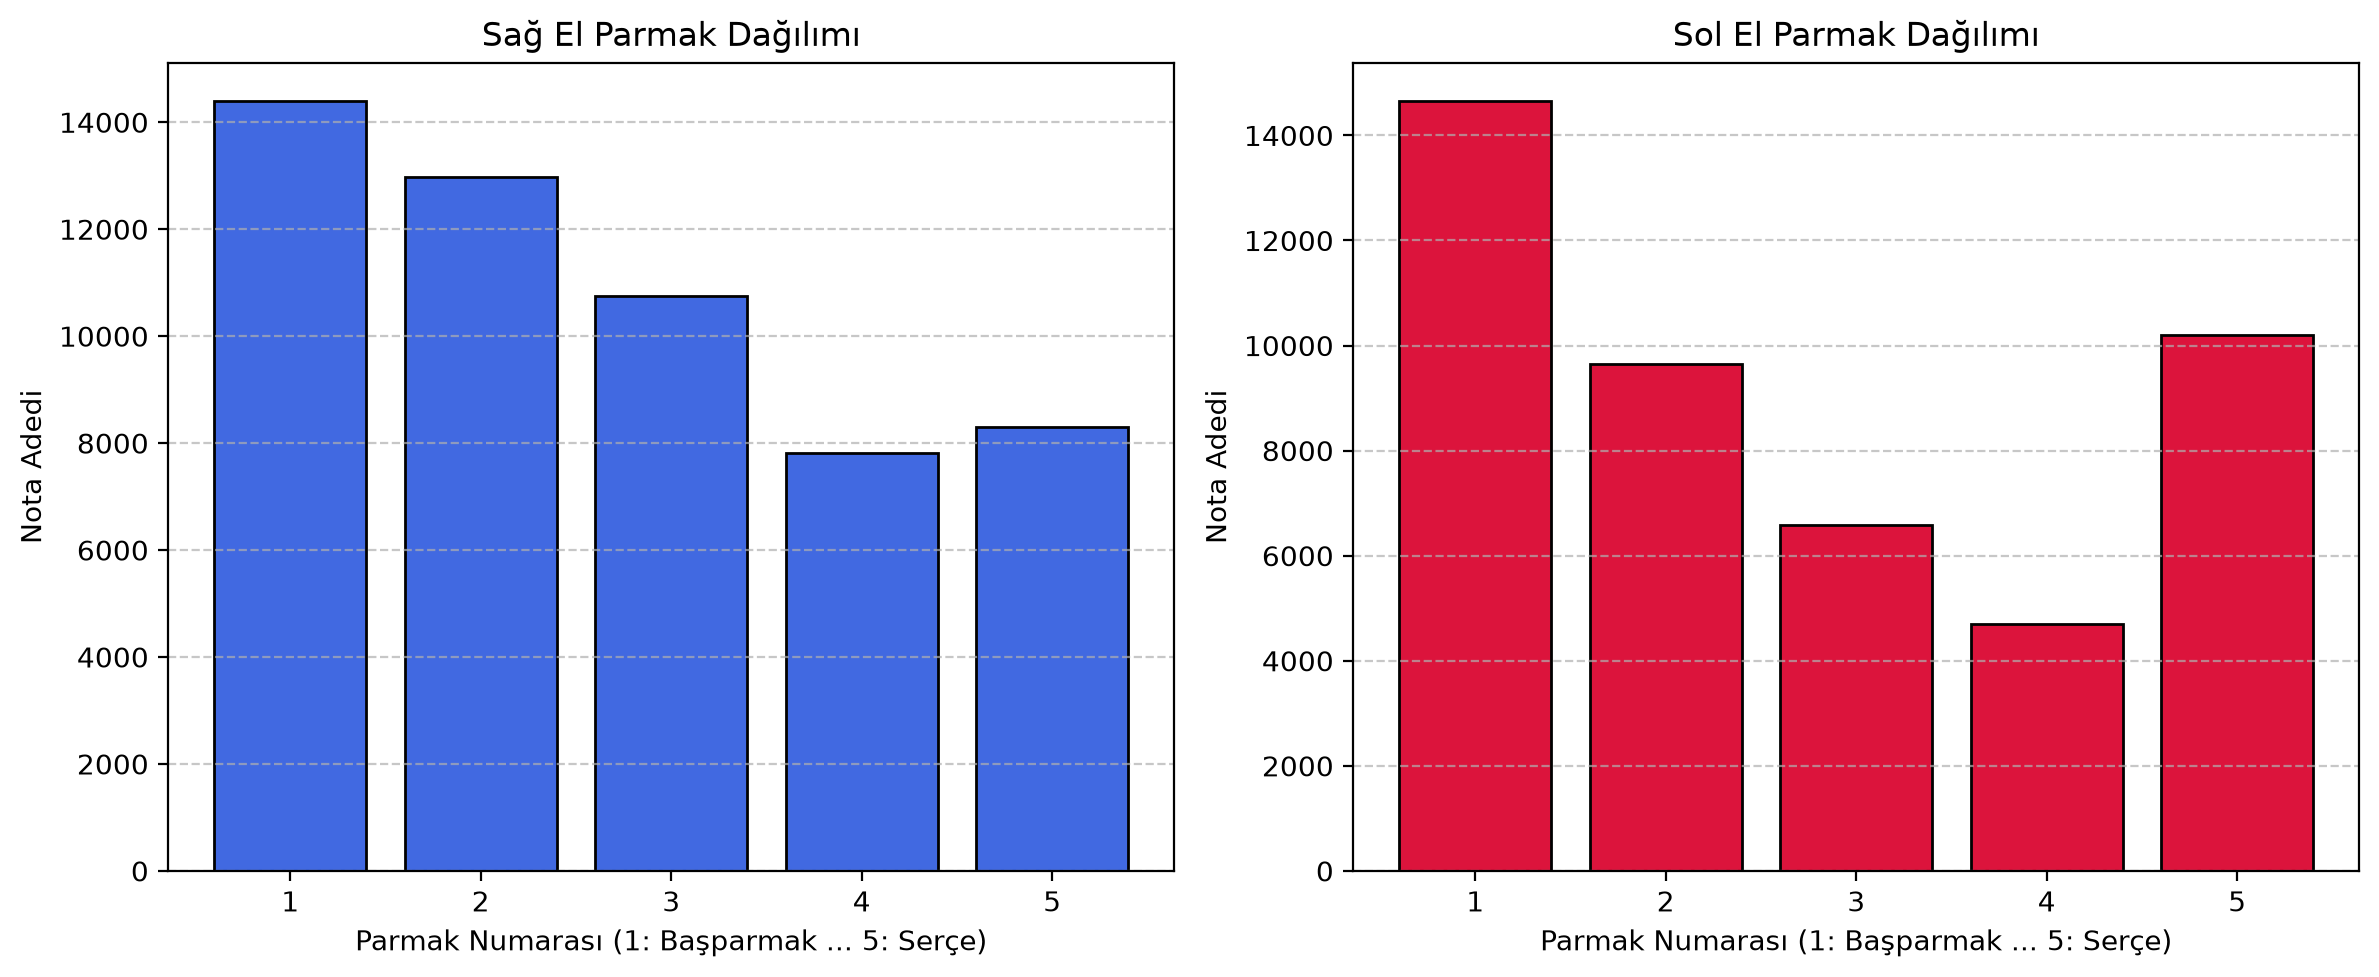

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(right_hand_counts.index, right_hand_counts.values, color="royalblue", edgecolor="black")
axes[0].set_title("Sağ El Parmak Dağılımı")
axes[0].set_xlabel("Parmak Numarası (1: Başparmak ... 5: Serçe)")
axes[0].set_ylabel("Nota Adedi")
axes[0].set_xticks(range(1, 6))
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

axes[1].bar(left_hand_counts.index, left_hand_counts.values, color="crimson", edgecolor="black")
axes[1].set_title("Sol El Parmak Dağılımı")
axes[1].set_xlabel("Parmak Numarası (1: Başparmak ... 5: Serçe)")
axes[1].set_ylabel("Nota Adedi")
axes[1].set_xticks(range(1, 6))
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [17]:
import random
import numpy as np

piece_ids = sorted(list(set([os.path.basename(f).split("-")[0] for f in all_files])))
print(f"Toplam farklı eser sayısı: {len(piece_ids)}")

random.seed(59)
shuffled_pieces = piece_ids.copy()
random.shuffle(shuffled_pieces)

split_idx = int(len(shuffled_pieces) * 0.8)
train_pieces = set(shuffled_pieces[:split_idx])
test_pieces = set(shuffled_pieces[split_idx:])

train_files = [f for f in all_files if os.path.basename(f).split("-")[0] in train_pieces]
test_files = [f for f in all_files if os.path.basename(f).split("-")[0] in test_pieces]

print(f"traindeki eserler: {len(train_pieces)} | İlgili Dosya Sayısı: {len(train_files)}")
print(f"testdeki eserler: {len(test_pieces)} | İlgili Dosya Sayısı: {len(test_files)}")

Toplam farklı eser sayısı: 150
traindeki eserler: 120 | İlgili Dosya Sayısı: 235
testdeki eserler: 30 | İlgili Dosya Sayısı: 74
